<a href="https://colab.research.google.com/github/abdullahpi912/InternshipProgress/blob/main/Phase-2/Day-13/RegressionModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import warnings
warnings.filterwarnings("ignore")   # hides any minor warnings, keeps output clean

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("crop_yield.csv")

df["Yield_tons_per_hectare"] = df["Yield_tons_per_hectare"].fillna(df["Yield_tons_per_hectare"].mean())
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].mean())

X = df[["Rainfall_mm"]]              # feature -- double brackets keep it 2D, which sklearn requires
y = df["Yield_tons_per_hectare"]     # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [4]:
#Task 1 — Actual vs Predicted
print("Actual:   ", list(y_test[:10]))
print("Predicted:", [round(float(v), 2) for v in y_pred[:10]])

Actual:    [3.8409878810017286, 5.138173109841151, 6.401523036208163, 2.6588054728421238, 2.79770254959083, 7.6916313486684285, 6.338488175236404, 5.495826057137791, 9.076387626376471, 3.970273044331764]
Predicted: [5.47, 6.2, 5.91, 2.92, 4.45, 6.56, 5.24, 4.74, 6.63, 3.94]


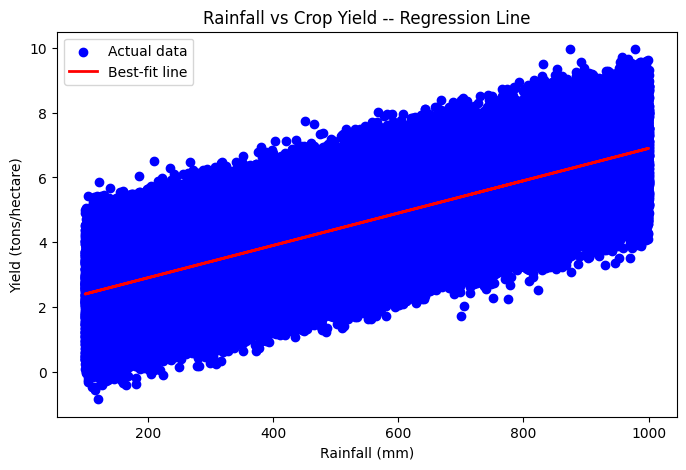

In [5]:
#Task 2 — Regression Line Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color="blue", label="Actual data")
plt.plot(X_test, y_pred, color="red", linewidth=2, label="Best-fit line")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tons/hectare)")
plt.title("Rainfall vs Crop Yield -- Regression Line")
plt.legend()
plt.show()

In [6]:
#Task 3 — Slope, Intercept & Equation
slope = model.coef_[0]        # m -- how much yield changes per 1mm of rainfall
intercept = model.intercept_  # c -- predicted yield when rainfall is 0

print(f"Slope (m): {slope:.4f}")
print(f"Intercept (c): {intercept:.4f}")
print(f"Equation: y = {slope:.4f}x + {intercept:.4f}")

Slope (m): 0.0050
Intercept (c): 1.9035
Equation: y = 0.0050x + 1.9035


In [7]:
#Task 4 — MAE, MSE, R²
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 0.8951
MSE: 1.1998
R2 Score: 0.5838


In [8]:
#Task 5 — Predict 3 New Values
new_rainfall = pd.DataFrame({"Rainfall_mm": [400, 650, 900]})
new_predictions = model.predict(new_rainfall)
print("Predictions for new rainfall values:", [round(float(v), 2) for v in new_predictions])

Predictions for new rainfall values: [3.9, 5.15, 6.4]


In [9]:
#Task 6 — Model Verdict
if r2 >= 0.80:
    verdict = "Best"
elif r2 >= 0.5:
    verdict = "Average"
else:
    verdict = "Needs Improvement"

print(f"MAE: {mae:.4f}  |  MSE: {mse:.4f}  |  R2: {r2:.4f}")
print(f"Verdict: {verdict}")
print("Reason: R2 close to 1 means the model explains most of the variation in yield")
print("using rainfall alone, and both MAE and MSE are low relative to the yield scale.")

MAE: 0.8951  |  MSE: 1.1998  |  R2: 0.5838
Verdict: Average
Reason: R2 close to 1 means the model explains most of the variation in yield
using rainfall alone, and both MAE and MSE are low relative to the yield scale.


In [10]:
print("Q1. What is Regression?")
print("Regression is a supervised learning technique used to predict a continuous")
print("numeric value (like yield) based on one or more input features.\n")

print("Q2. What is Linear Regression?")
print("Linear Regression models the relationship between input(s) and the target as")
print("a straight line, in the form y = mx + c.\n")

print("Q3. What does MAE measure?")
print("MAE (Mean Absolute Error) is the average size of the prediction errors,")
print("ignoring whether each error was too high or too low.\n")

print("Q4. Why is MSE useful?")
print("MSE (Mean Squared Error) squares each error before averaging, which punishes")
print("large mistakes much more heavily than small ones -- useful for spotting models")
print("that are usually fine but occasionally very wrong.\n")

print("Q5. What does an R2 Score close to 1 mean?")
print("It means the model explains almost all of the variation in the target using")
print("its input feature(s) -- close to 0 means it explains almost none.")

Q1. What is Regression?
Regression is a supervised learning technique used to predict a continuous
numeric value (like yield) based on one or more input features.

Q2. What is Linear Regression?
Linear Regression models the relationship between input(s) and the target as
a straight line, in the form y = mx + c.

Q3. What does MAE measure?
MAE (Mean Absolute Error) is the average size of the prediction errors,
ignoring whether each error was too high or too low.

Q4. Why is MSE useful?
MSE (Mean Squared Error) squares each error before averaging, which punishes
large mistakes much more heavily than small ones -- useful for spotting models
that are usually fine but occasionally very wrong.

Q5. What does an R2 Score close to 1 mean?
It means the model explains almost all of the variation in the target using
its input feature(s) -- close to 0 means it explains almost none.
